In [ ]:
# Install required libraries
!pip install transformers
!pip install datasets

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import GPT2LMHeadModel, GPT2Tokenizer, Trainer, TrainingArguments
from datasets import Dataset


# Load datasets
train_data = pd.read_csv('/content/train_data.csv')
test_data = pd.read_csv('/content/test_data.csv')

In [ ]:
# Preprocess data: Convert the 'News Content in Detail' column to a format suitable for the model
train_texts = train_data['News Content in Detail'].tolist()
test_texts = test_data['News Content in Detail'].tolist()


In [ ]:
# Tokenization
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
# Add padding token
tokenizer.pad_token = tokenizer.eos_token
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=512)
test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=512)

In [ ]:

# Convert to Dataset format
train_dataset = Dataset.from_dict({
    'input_ids': train_encodings['input_ids'],
    'attention_mask': train_encodings['attention_mask'],
    'labels': train_encodings['input_ids']  # Add labels here
})
test_dataset = Dataset.from_dict({
    'input_ids': test_encodings['input_ids'],
    'attention_mask': test_encodings['attention_mask'],
    'labels': test_encodings['input_ids']   # Add labels here
})
# Load model
model = GPT2LMHeadModel.from_pretrained('gpt2')


In [ ]:
# Define TrainingArguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=1,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
)

# Create Trainer instance
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

# Train the model
trainer.train()

# Save the trained model
model.save_pretrained('/content/trained_gpt2_model')
tokenizer.save_pretrained('/content/trained_gpt2_model')

Step,Training Loss


('/content/trained_gpt2_model/tokenizer_config.json',
 '/content/trained_gpt2_model/special_tokens_map.json',
 '/content/trained_gpt2_model/vocab.json',
 '/content/trained_gpt2_model/merges.txt',
 '/content/trained_gpt2_model/added_tokens.json')

In [ ]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# Load the trained model and tokenizer
model_path = '/content/trained_gpt2_model'
model = GPT2LMHeadModel.from_pretrained(model_path)
tokenizer = GPT2Tokenizer.from_pretrained(model_path)

# Define a function to generate summaries
def generate_summary(text, max_length=150, num_beams=5, no_repeat_ngram_size=2):
    inputs = tokenizer.encode(text, return_tensors='pt', max_length=1024, truncation=True)
    summary_ids = model.generate(
        inputs,
        max_length=max_length,
        num_beams=num_beams,
        no_repeat_ngram_size=no_repeat_ngram_size,
        early_stopping=True
    )
    summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
    return summary

# Example text
example_text = """
GPT-2 is a transformer-based model developed by OpenAI. It is designed to generate coherent and contextually relevant text based on the input prompt. The model was trained on a diverse range of internet text and can generate human-like text that is often indistinguishable from that written by a person. However, it should be noted that GPT-2 does not have an understanding of the world; it generates text based on patterns it learned during training.
"""

# Generate and print summary
summary = generate_summary(example_text)
print("Generated Summary:", summary)


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token.As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Generated Summary: 
GPT-2 is a transformer-based model developed by OpenAI. It is designed to generate coherent and contextually relevant text based on the input prompt. The model was trained on a diverse range of internet text and can generate human-like text that is often indistinguishable from that written by a person. However, it should be noted that GPT-2 does not have an understanding of the world; it generates text based on patterns it learned during training.

In this paper, we present the results of a series of experiments in which we trained a set of text-generating robots to read and write human text. We show that the text generated by the robots can be translated into human language, and that this translates into a human


In [ ]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# Load the trained model and tokenizer
model_path = '/content/trained_gpt2_model'
model = GPT2LMHeadModel.from_pretrained(model_path)
tokenizer = GPT2Tokenizer.from_pretrained(model_path)

# Define a function to generate summaries with proper attention masks
def generate_summary(text, max_length=150, num_beams=5, no_repeat_ngram_size=2):
    inputs = tokenizer.encode_plus(text, return_tensors='pt', max_length=1024, truncation=True, padding='longest')
    input_ids = inputs['input_ids']
    attention_mask = inputs['attention_mask']

    summary_ids = model.generate(
        input_ids,
        attention_mask=attention_mask,
        max_length=max_length,
        num_beams=num_beams,
        no_repeat_ngram_size=no_repeat_ngram_size,
        early_stopping=True,
        pad_token_id=tokenizer.eos_token_id  # Ensure that the pad token id is set correctly
    )
    summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
    return summary




Generated Summary: 
GPT-2 is a transformer-based model developed by OpenAI. It is designed to generate coherent and contextually relevant text based on the input prompt. The model was trained on a diverse range of internet text and can generate human-like text that is often indistinguishable from that written by a person. However, it should be noted that GPT-2 does not have an understanding of the world; it generates text based on patterns it learned during training.

In this paper, we present the results of a series of experiments in which we trained a set of text-generating robots to read and write human text. We show that the text generated by the robots can be translated into human language, and that this translates into a human


In [ ]:
# Example text
example_text = """
In a significant advancement, TechCorp has unveiled a new artificial intelligence model that promises to revolutionize the industry. The model, dubbed "AlphaAI," boasts unprecedented capabilities in natural language processing and machine learning. During a press conference, CEO Jane Smith highlighted that AlphaAI can understand and generate human-like text with remarkable accuracy. This breakthrough is expected to enhance customer service, streamline data analysis, and accelerate research in various fields. TechCorp's innovation has sparked excitement across the tech community, with experts predicting it will set new standards for AI development."""

print("Text = ", example_text)
# Generate and print summary
summary = generate_summary(example_text)
print("Generated Summary:", summary)

Text =  
In a significant advancement, TechCorp has unveiled a new artificial intelligence model that promises to revolutionize the industry. The model, dubbed "AlphaAI," boasts unprecedented capabilities in natural language processing and machine learning. During a press conference, CEO Jane Smith highlighted that AlphaAI can understand and generate human-like text with remarkable accuracy. This breakthrough is expected to enhance customer service, streamline data analysis, and accelerate research in various fields. TechCorp's innovation has sparked excitement across the tech community, with experts predicting it will set new standards for AI development.
Generated Summary: 
In a significant advancement, TechCorp has unveiled a new artificial intelligence model that promises to revolutionize the industry. The model, dubbed "AlphaAI," boasts unprecedented capabilities in natural language processing and machine learning. During a press conference, CEO Jane Smith highlighted that AlphaAI

### Training the model

Model: "pointer_generator_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       multiple                  12800000  
                                                                 
 lstm (LSTM)                 multiple                  1574912   
                                                                 
 time_distributed (TimeDist  multiple                  25650000  
 ributed)                                                        
                                                                 
Total params: 40024912 (152.68 MB)
Trainable params: 40024912 (152.68 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/10
3/3 [==============================] - 73s 21s/step - loss: 10.8074 - accuracy: 0.5200 - val_loss: 10.7299 - val_accuracy: 0.8750
Epoch 2/10
3/3 [==============================] - 52s 19

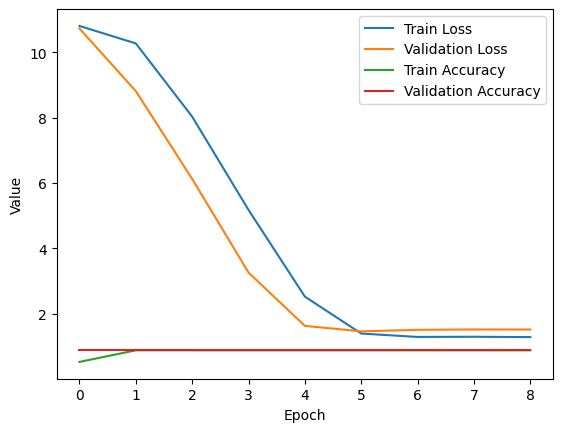

In [ ]:

import tensorflow as tf
from tensorflow.keras.layers import Embedding, LSTM, Dense, TimeDistributed
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping  # Import EarlyStopping
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

class PointerGeneratorModel(Model):
    def __init__(self, vocab_size, embedding_dim, units):
        super(PointerGeneratorModel, self).__init__()
        self.embedding = Embedding(vocab_size, embedding_dim)
        self.lstm = LSTM(units, return_sequences=True)
        self.dense = TimeDistributed(Dense(vocab_size, activation='softmax'))

    def call(self, x):
        x = self.embedding(x)
        output = self.lstm(x)
        output = self.dense(output)
        return output

# Hyperparameters
vocab_size = 50000
embedding_dim = 256
units = 512
max_sequence_length = 80

# Load and preprocess the dataset
file_path = '/content/synthetic_news_dataset.csv'
data = pd.read_csv(file_path)

# Extract relevant columns
texts = data['News Content in Detail'].astype(str).tolist()
summaries1 = data['News Content Summary (20 words)'].astype(str).tolist()

# Tokenize texts and summaries
tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(texts + summaries1)

# Preprocess sequences and summaries
def preprocess_texts(texts, tokenizer, max_len):
    sequences = tokenizer.texts_to_sequences(texts)
    padded_sequences = tf.keras.preprocessing.sequence.pad_sequences(sequences, maxlen=max_len, padding='post')
    return np.array(padded_sequences)

sequences = preprocess_texts(texts, tokenizer, max_sequence_length)
summaries = preprocess_texts(summaries1, tokenizer, max_sequence_length)

# Split the data into training and validation sets
train_sequences, val_sequences, train_summaries, val_summaries = train_test_split(
    sequences, summaries, test_size=0.1, random_state=42
)

# Create the model
model = PointerGeneratorModel(vocab_size, embedding_dim, units)

# Build the model by providing the input shape
model.build(input_shape=(None, max_sequence_length))

# Compile the model with accuracy metric
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Summarize the model
model.summary()

# Define batch size and epochs
BATCH_SIZE = 32
EPOCHS = 10

# Early stopping to avoid overfitting
early_stopping = EarlyStopping(monitor='val_loss',
                               patience=3,
                               restore_best_weights=True)

# Train the model
history = model.fit(
    train_sequences,
    np.expand_dims(train_summaries, -1),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(val_sequences, np.expand_dims(val_summaries, -1)),
    callbacks=[early_stopping]
)

# Evaluate the model
val_loss, val_accuracy = model.evaluate(val_sequences, np.expand_dims(val_summaries, -1))
print(f'Validation Loss: {val_loss}')
print(f'Validation Accuracy: {val_accuracy}')

# Plot training and validation metrics
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.show()


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Define a function to preprocess the input text
def preprocess_text(text, tokenizer, max_len):
    sequence = tokenizer.texts_to_sequences([text])
    padded_sequence = pad_sequences(sequence, maxlen=max_len, padding='post')
    return np.array(padded_sequence)

# Define a function to decode the predicted sequence back to text
def decode_sequence(sequence, tokenizer):
    reverse_word_index = {index: word for word, index in tokenizer.word_index.items()}
    words = [reverse_word_index.get(index, '<UNK>') for index in sequence if index != 0]
    return ' '.join(words).strip()

# Summarize a new text
def summarize_text(text, model, tokenizer, max_sequence_length):
    # Preprocess the input text
    input_sequence = preprocess_text(text, tokenizer, max_sequence_length)

    # Generate the summary
    predictions = model.predict(input_sequence)

    # Print raw predictions
    print("Raw Predictions Shape:", predictions.shape)
    print("Raw Predictions Sample:", predictions[0, :5])

    # Extract the predicted token indices
    predicted_indices = np.argmax(predictions, axis=-1)[0]

    # Print predicted indices
    print("Predicted Indices:", predicted_indices)

    # Remove padding tokens (assuming padding token index is 0)
    predicted_indices = [index for index in predicted_indices if index != 0]

    # Decode the predicted indices to text
    summary = decode_sequence(predicted_indices, tokenizer)

    return summary

# Example new text to summarize
new_text = "Advancements in AI have changed how we interact with technology."

# Use the trained model to summarize the new text
summary = summarize_text(new_text, model, tokenizer, max_sequence_length)
print("Summary:", summary)


1/1 [==============================] - 1s 625ms/step
Raw Predictions Shape: (1, 80, 50000)
Raw Predictions Sample: [[2.2930071e-05 2.1442247e-05 2.1161406e-05 ... 1.9986941e-05
  2.0010095e-05 1.9993036e-05]
 [2.8027065e-05 2.3148141e-05 2.2681679e-05 ... 1.9960824e-05
  2.0042682e-05 1.9983490e-05]
 [4.7207064e-05 2.8108903e-05 2.7171496e-05 ... 1.9960185e-05
  2.0061983e-05 1.9941837e-05]
 [1.5688877e-04 4.4046930e-05 4.1218555e-05 ... 1.9911788e-05
  2.0078494e-05 1.9802283e-05]
 [3.8186584e-03 1.4302455e-04 1.2280112e-04 ... 1.9497538e-05
  1.9829196e-05 1.9124516e-05]]
Predicted Indices: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0]
Summary: 
